In [1]:
pwd


'C:\\Users\\91918\\rna seq'

In [3]:
import os
os.chdir("C:/Users/91918/")

In [4]:
pwd

'C:\\Users\\91918'

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import linregress

# Load overlapping genes from Step 
overlap = pd.read_excel("C:/Users/91918/overlapping_deg_dep_genes.xlsx")

In [10]:
# Extract log fold-change values
x = overlap['log2FoldChange']        # Transcriptome (DEGs) # x: Transcriptome log2 Fold Change (DEGs) → How much gene expression changes in RNA-seq.
y = overlap['AVG Log2 Ratio']

In [11]:
# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

In [12]:
x_vals = np.linspace(min(x), max(x), 100)  
y_vals = slope * x_vals + intercept

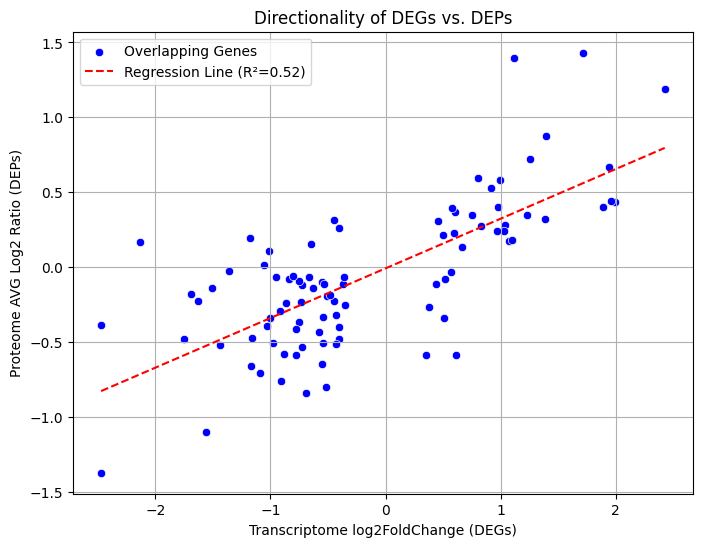

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=x, y=y, color='blue', label="Overlapping Genes")
plt.plot(x_vals, y_vals, color='red', linestyle='dashed', label=f"Regression Line (R²={r_value**2:.2f})")

# Labels and title
plt.xlabel("Transcriptome log2FoldChange (DEGs)")
plt.ylabel("Proteome AVG Log2 Ratio (DEPs)")
plt.title("Directionality of DEGs vs. DEPs")
plt.legend()                                         # displays the legend box (for the blue dots and red line).
plt.grid(True)                                       #  Adds a grid to improve readability.


# Save plot
#plt.savefig("C:/Users/91918/Directionality_Plot_Y_AL vs NRDR.png", dpi=300)

# Show plot
plt.show()

In [14]:
print(f"Linear Regression Equation: y = {slope:.4f}x + {intercept:.4f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4e}")

Linear Regression Equation: y = 0.3316x + -0.0089
R-squared: 0.5217
P-value: 6.4752e-16
